# Restoration of Degraded Medical Images Using Spatial Filtering

This notebook demonstrates how to restore noisy medical images using linear and non-linear spatial filters.

## 1. Add Noise to the Medical Image

We will add Gaussian, Salt & Pepper, and Speckle noise with different densities.

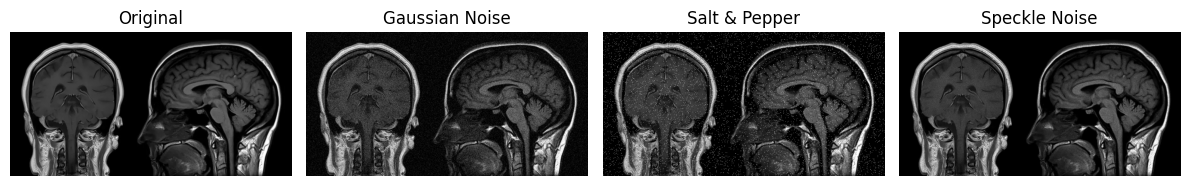

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import wiener

# Load grayscale medical image (replace with your filename if needed)
img = cv2.imread('mri.jpeg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise Exception('Image not found!')

# Add Gaussian noise
def add_gaussian_noise(image, sigma):
    gauss = np.random.normal(0, sigma, image.shape).astype(np.float32)
    noisy = image.astype(np.float32) + gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

# Add Salt & Pepper noise
def add_salt_pepper_noise(image, density):
    noisy = image.copy()
    num_salt = np.ceil(density * image.size * 0.5).astype(int)
    num_pepper = np.ceil(density * image.size * 0.5).astype(int)
    
    # Salt
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255
    
    # Pepper
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

# Add Speckle noise
def add_speckle_noise(image, var):
    gauss = np.random.randn(*image.shape) * var
    noisy = image + image * gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

# Example: Add noise with density 0.05
gauss_img = add_gaussian_noise(img, sigma=20)
sp_img = add_salt_pepper_noise(img, density=0.05)
speckle_img = add_speckle_noise(img, var=0.1)

plt.figure(figsize=(12,4))
plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(gauss_img, cmap='gray')
plt.title('Gaussian Noise')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(sp_img, cmap='gray')
plt.title('Salt & Pepper')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(speckle_img, cmap='gray')
plt.title('Speckle Noise')
plt.axis('off')

plt.tight_layout()
plt.show()

## 2. Apply Linear and Non-Linear Filters

We will use Mean, Gaussian, Median, and Wiener filters with different mask sizes to restore the noisy images.

C:\Users\himan\AppData\Roaming\Python\Python313\site-packages\scipy\signal\_signaltools.py:1783: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
C:\Users\himan\AppData\Roaming\Python\Python313\site-packages\scipy\signal\_signaltools.py:1783: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
C:\Users\himan\AppData\Local\Temp\ipykernel_20216\3792227326.py:12: RuntimeWarning: invalid value encountered in cast
  wiener_3 = np.clip(wiener_3, 0, 255).astype(np.uint8)
C:\Users\himan\AppData\Local\Temp\ipykernel_20216\3792227326.py:13: RuntimeWarning: invalid value encountered in cast
  wiener_5 = np.clip(wiener_5, 0, 255).astype(np.uint8)


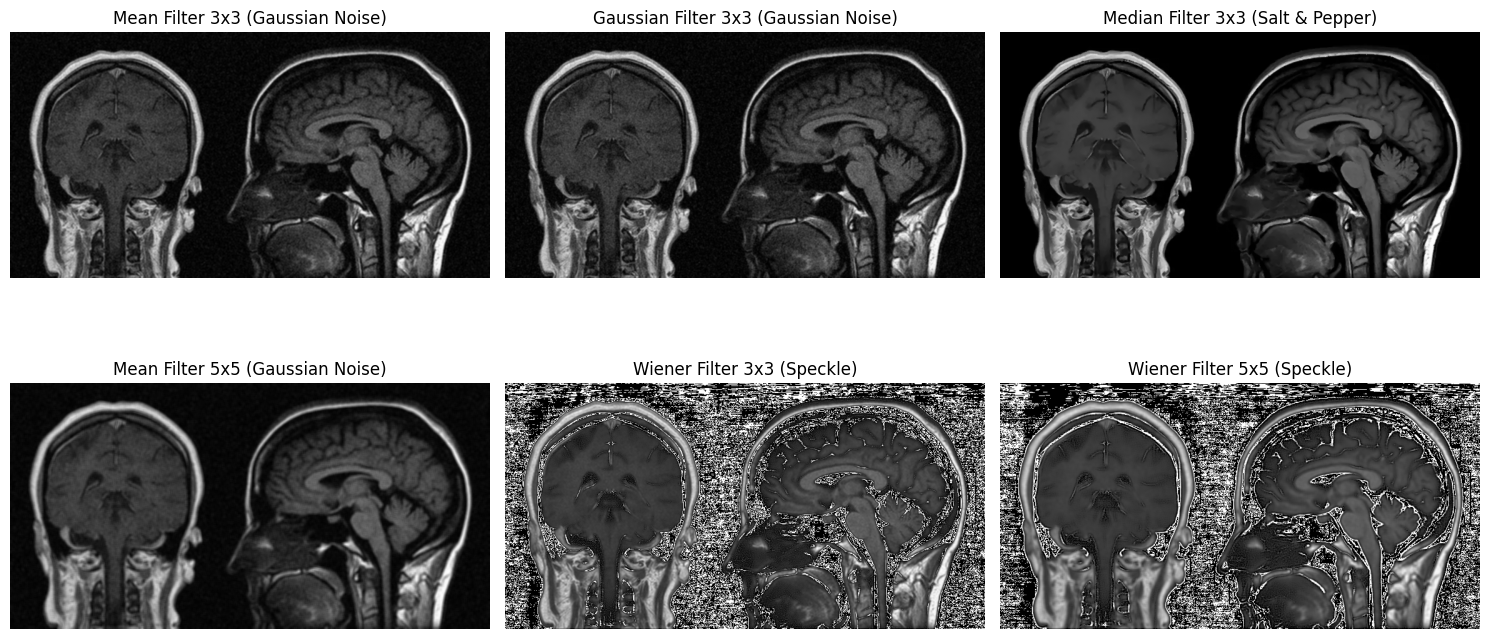

In [2]:
# Linear Filters
mean_3 = cv2.blur(gauss_img, (3,3))
mean_5 = cv2.blur(gauss_img, (5,5))
gauss_filt_3 = cv2.GaussianBlur(gauss_img, (3,3), 1)
gauss_filt_5 = cv2.GaussianBlur(gauss_img, (5,5), 1)

# Non-Linear Filters
median_3 = cv2.medianBlur(sp_img, 3)
median_5 = cv2.medianBlur(sp_img, 5)
wiener_3 = wiener(speckle_img, (3,3))
wiener_5 = wiener(speckle_img, (5,5))
wiener_3 = np.clip(wiener_3, 0, 255).astype(np.uint8)
wiener_5 = np.clip(wiener_5, 0, 255).astype(np.uint8)

plt.figure(figsize=(15,8))
plt.subplot(2,3,1)
plt.imshow(mean_3, cmap='gray')
plt.title('Mean Filter 3x3 (Gaussian Noise)')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(gauss_filt_3, cmap='gray')
plt.title('Gaussian Filter 3x3 (Gaussian Noise)')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(median_3, cmap='gray')
plt.title('Median Filter 3x3 (Salt & Pepper)')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(mean_5, cmap='gray')
plt.title('Mean Filter 5x5 (Gaussian Noise)')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(wiener_3, cmap='gray')
plt.title('Wiener Filter 3x3 (Speckle)')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(wiener_5, cmap='gray')
plt.title('Wiener Filter 5x5 (Speckle)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Quantitative Comparison: PSNR and MSE

We will compare the performance of each filter using Peak Signal-to-Noise Ratio (PSNR) and Mean Squared Error (MSE).

In [ ]:
def mse(img1, img2):
    return np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)

def psnr(img1, img2):
    mse_val = mse(img1, img2)
    if mse_val == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse_val))

print('PSNR and MSE for Gaussian Noise:')
print('Mean 3x3:', psnr(img, mean_3), mse(img, mean_3))
print('Gaussian 3x3:', psnr(img, gauss_filt_3), mse(img, gauss_filt_3))
print('\nPSNR and MSE for Salt & Pepper Noise:')
print('Median 3x3:', psnr(img, median_3), mse(img, median_3))
print('\nPSNR and MSE for Speckle Noise:')
print('Wiener 3x3:', psnr(img, wiener_3), mse(img, wiener_3))

PSNR and MSE for Gaussian Noise:
Mean 3x3: 28.293522862999954 96.32257
Gaussian 3x3: 28.642445982682375 88.88649

PSNR and MSE for Salt & Pepper Noise:
Median 3x3: 33.7213377551099 27.602385

PSNR and MSE for Speckle Noise:
Wiener 3x3: 7.819565042093374 10742.958


## 4. Discussion: Best Filter for Each Noise Type

- **Gaussian Noise:** Mean and Gaussian filters are effective, with Gaussian filter slightly better for edge preservation.
- **Salt & Pepper Noise:** Median filter is most effective, as it removes isolated noise without blurring edges.
- **Speckle Noise:** Wiener filter adapts to local variance and works best for this type of multiplicative noise.
- **Quantitative Results:** Higher PSNR and lower MSE indicate better restoration. Visual inspection should confirm that edges and fine details are preserved while noise is reduced.

**Conclusion:**
- Use Gaussian/Mean filter for Gaussian noise, Median filter for Salt & Pepper noise, and Wiener filter for Speckle noise in medical image restoration tasks.